<a href="https://colab.research.google.com/github/dalmasm/AI/blob/Data-Science/AIEngineer_2025_Neural_Networks_Multiclass_Classification_Pytorch_MNIST_Digits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [13]:
# Configurar el dispositivo: GPU si está disponible, de lo contrario CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
# Hiperparámetros
batch_size = 64  # Tamaño del lote para la carga de datos
learning_rate = 0.001  # Tasa de aprendizaje para el optimizador
epochs = 10  # Número de épocas para el entrenamiento

In [15]:
# Preparar los datos: Normalización y conversión a tensores
transform = transforms.Compose([
    transforms.ToTensor(),  # Convertir imágenes a tensores
    transforms.Normalize((0.5,), (0.5,))  # Normalizar los datos con media 0.5 y desviación estándar 0.5
])

# Descargar y cargar el conjunto de datos MNIST
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Crear cargadores de datos para entrenamiento y prueba
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [16]:
# Definir la red neuronal
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        # Primera capa totalmente conectada
        self.fc1 = nn.Linear(28 * 28, 128)  # 28x28 es el tamaño de la imagen de entrada
        # Segunda capa completamente conectada
        self.fc2 = nn.Linear(128, 64)
        # Capa de salida con 10 nodos (para las 10 clases: dígitos 0-9)
        self.fc3 = nn.Linear(64, 10)
        # Función de activación ReLU
        self.relu = nn.ReLU()
        # Capa de regularización Dropout para evitar sobreajuste
        self.dropout = nn.Dropout(0.2)
        # Softmax para normalizar las probabilidades de las clases
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        # Aplanar la imagen de entrada en un vector
        x = x.view(-1, 28 * 28)
        # Pasar por la primera capa y aplicar ReLU
        x = self.relu(self.fc1(x))
        x = self.dropout(x)  # Aplicar Dropout
        # Pasar por la segunda capa y aplicar ReLU
        x = self.relu(self.fc2(x))
        x = self.dropout(x)  # Aplicar Dropout
        # Pasar por la capa de salida
        x = self.fc3(x)
        return self.softmax(x)  # Devolver las probabilidades normalizadas

In [17]:
# Inicializar modelo, función de pérdida y optimizador
model = NeuralNet().to(device)  # Mover el modelo al dispositivo (CPU o GPU)
criterion = nn.NLLLoss()  # Función de pérdida de log-verosimilitud negativa
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # Optimizador Adam

In [18]:
# Función para visualizar una predicción
def visualize_prediction(data, pred, epoch):
    # Convertir datos de PyTorch a numpy para visualización
    data = data.cpu().numpy().squeeze()
    pred = pred.cpu().numpy()

    # Mostrar la imagen con su predicción
    plt.imshow(data, cmap='gray')
    plt.title(f"Época {epoch+1}, Predicción: {pred}")
    plt.axis('off')
    plt.show()

In [19]:
# Loop de entrenamiento
def train(model, loader, optimizer, criterion, device):
    model.train()  # Poner el modelo en modo de entrenamiento
    for epoch in range(epochs):
        epoch_loss = 0  # Inicializar pérdida acumulada de la época
        correct = 0  # Contador de predicciones correctas
        for batch_idx, (data, target) in enumerate(loader):
            # Mover los datos y etiquetas al dispositivo
            data, target = data.to(device), target.to(device)

            # feedforward: calcular salida del modelo
            output = model(data)
            # Calcular la pérdida entre salida y objetivo
            loss = criterion(output, target)

            # backpropagation: limpiar gradientes, retropropagar y actualizar weights
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Acumular pérdida de esta iteración
            epoch_loss += loss.item()
            # Calcular predicciones correctas
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

            # Visualizar la predicción de la primera imagen del lote en cada época
            if batch_idx == 0:
                visualize_prediction(data[0], pred[0], epoch)

        # Imprimir loss y precisión de la época (pasada)
        print(f"Época {epoch+1}/{epochs}, Pérdida: {epoch_loss/len(loader):.4f}, Precisión: {correct/len(loader.dataset)*100:.2f}%")

In [20]:
# Función de evaluación del modelo
def test(model, loader, criterion, device):
    model.eval()  # Poner el modelo en modo de evaluación
    test_loss = 0  # Inicializar pérdida acumulada del conjunto de prueba
    correct = 0  # Contador de predicciones correctas
    with torch.no_grad():  # Desactivar gradientes para evaluación
        for data, target in loader:
            # Mover datos y etiquetas al dispositivo
            data, target = data.to(device), target.to(device)

            # Calcular salida del modelo
            output = model(data)
            # Acumular la pérdida
            test_loss += criterion(output, target).item()
            # Calcular predicciones correctas
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    # Calcular pérdida promedio y precisión
    test_loss /= len(loader)
    accuracy = correct / len(loader.dataset) * 100
    print(f"Pérdida en prueba: {test_loss:.4f}, Precisión: {accuracy:.2f}%")
    return accuracy

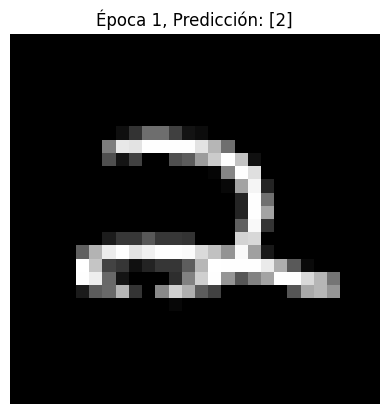

Época 1/10, Pérdida: 0.4818, Precisión: 85.01%


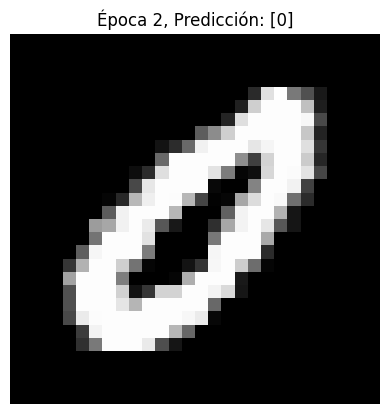

Época 2/10, Pérdida: 0.2519, Precisión: 92.39%


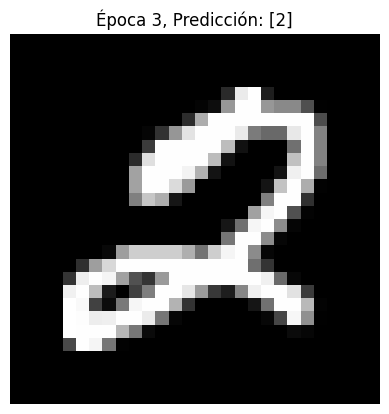

Época 3/10, Pérdida: 0.2046, Precisión: 93.76%


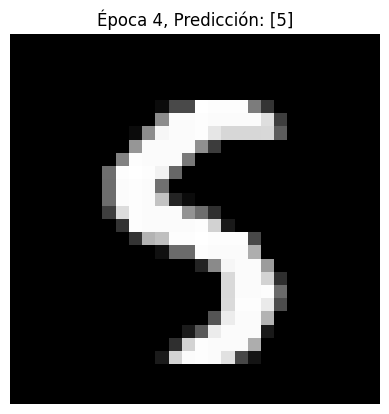

Época 4/10, Pérdida: 0.1841, Precisión: 94.43%


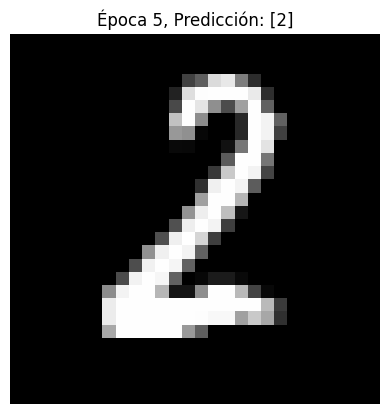

Época 5/10, Pérdida: 0.1624, Precisión: 94.99%


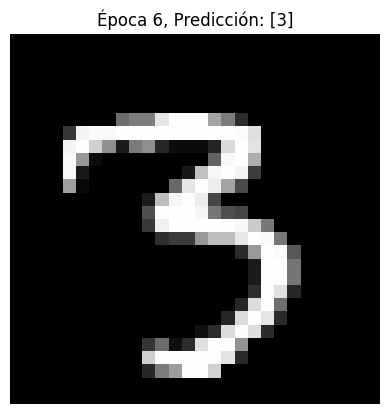

Época 6/10, Pérdida: 0.1522, Precisión: 95.33%


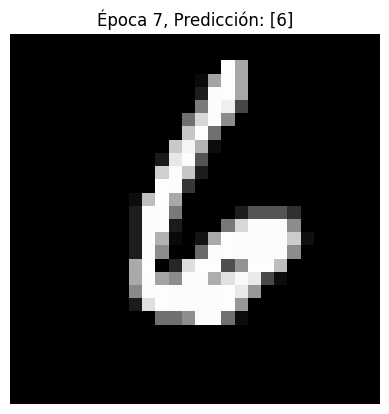

Época 7/10, Pérdida: 0.1486, Precisión: 95.45%


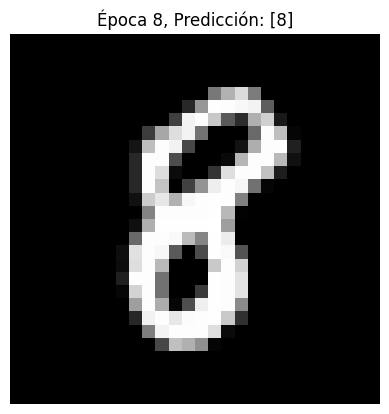

Época 8/10, Pérdida: 0.1385, Precisión: 95.75%


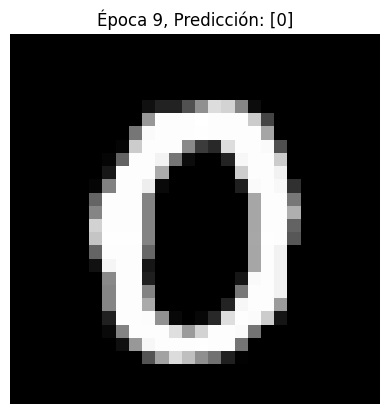

Época 9/10, Pérdida: 0.1339, Precisión: 95.84%


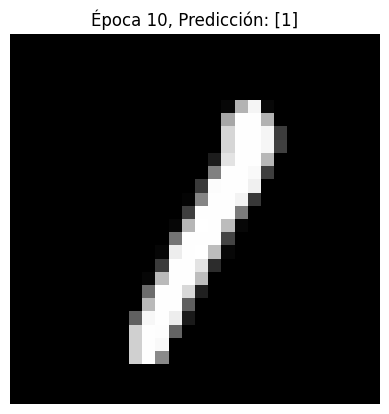

Época 10/10, Pérdida: 0.1278, Precisión: 96.06%
Pérdida en prueba: 0.0834, Precisión: 97.35%


97.35000000000001

In [11]:
# Entrenar el modelo
train(model, train_loader, optimizer, criterion, device)
# Evaluar el modelo contra el test dataset
test(model, test_loader, criterion, device)
